 # 目标设定与监控（Goal Setting and Monitoring）



- 智能代理需要的不仅是处理信息或使用工具的能力，还需明确方向与衡量成功的方式。
- 目标设定与监控模式：为代理提供具体目标并赋予跟踪进展与判定是否达成的手段。

1. 模式概览（Goal Setting and Monitoring Pattern）
   - 类比：规划一次旅行（目标状态、初始状态、可选方案、分步骤执行）。
   - 核心思想：通过分解目标、考虑依赖与约束，形成可执行的步骤序列或计划。
   - 在代理系统中的含义：代理从高层目标出发，自动或半自动地生成中间步骤/子目标并执行。
   - 执行形式：步骤可按顺序、并行或更复杂地与工具调用、路由、多代理协同结合。
   - 规划机制：可用搜索算法、逻辑推理，或利用大型语言模型（LLMs）基于训练数据生成计划。
   - 能力价值：支持处理复杂、多面任务、适应变化（重规划），将被动系统转为能主动追求目标的系统。

2. 关键功能与要点
   - 目标分解（高层目标 → 子目标/步骤）
   - 监控与度量（为每步设定成功指标）
   - 重规划与适应（环境变化或失败时重新规划）
   - 升级/人工干预机制（在必要时转人工处理）
   - 多代理/工具协同（与其他模式结合）

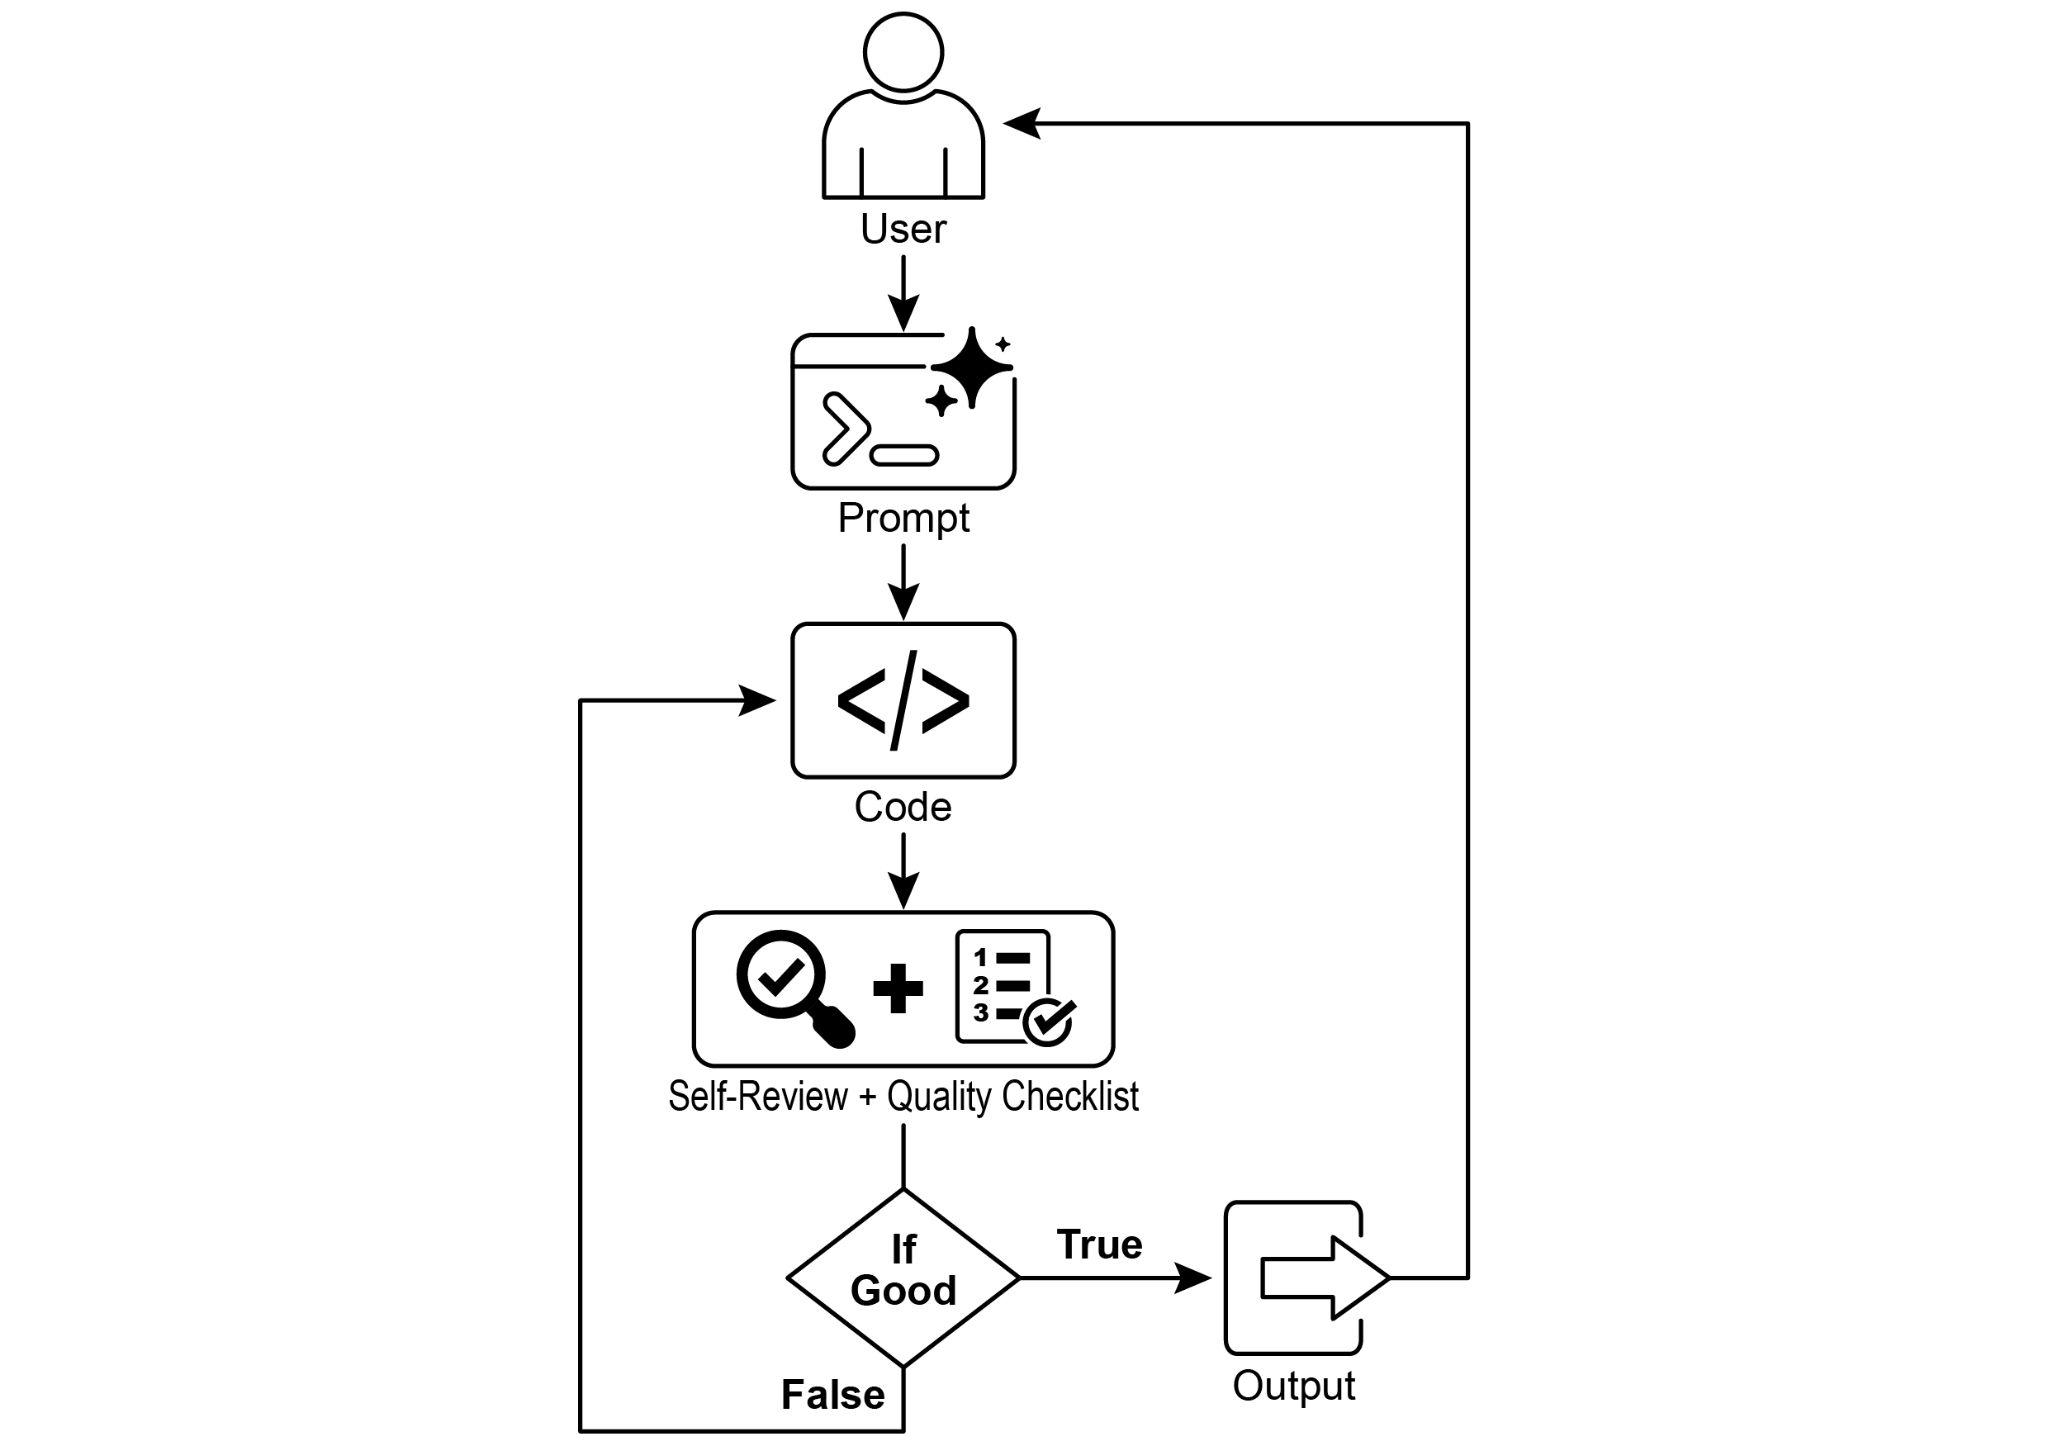



## 实践应用与用例
1. 客户支持自动化（Customer Support Automation）
   - 目标示例：解决客户的计费问题。
   - 动作：监控对话、查询数据库、使用工具调整计费。
   - 成功指标：账单变更确认 + 客户正面反馈；若未解决则升级到人工客服。

2. 个性化学习系统（Personalized Learning Systems）
   - 目标示例：提高学生对某一知识点（如代数）的掌握程度。
   - 动作：监测练习完成情况、正确率、完成时间；调整题目难度与教学材料。

3. 项目管理助手（Project Management Assistants）
   - 目标示例：确保里程碑 X 在 Y 日期前完成。
   - 动作：监控任务状态、团队沟通与资源，标记延迟并建议纠正措施。

4. 自动化交易机器人（Automated Trading Bots）
   - 目标示例：在风险容忍范围内最大化投资组合回报。
   - 动作：持续监测市场、仓位与风险指标，按策略执行交易并在阈值触发时调整。

5. 机器人与自动驾驶（Robotics and Autonomous Vehicles）
   - 目标示例：将乘客从 A 点安全送到 B 点。
   - 动作：实时监控周边环境（行人、车辆、信号）、自身状态（速度、燃料/电量），并根据路况调整行为。

6. 内容审核（Content Moderation）
   - 目标示例：识别并移除有害内容。
   - 动作：监控输入内容、应用分类模型、跟踪误判率（假阳性/假阴性），对模糊案例上报人工审核。



## 实践代码示例

这个 Python 脚本概述了一个旨在生成和完善 Python 代码的自主 AI 智能体。其核心功能是为指定的问题生成解决方案，确保符合用户定义的质量基准。

它采用"目标设定与监控"模式，不仅仅生成一次代码，而是进入创建、自我评估和改进的迭代循环。智能体的成功通过其自己的 AI 驱动的判断来衡量，判断生成的代码是否成功满足初始目标。最终输出是一个经过打磨、注释完善且可以立即使用的 Python 文件，代表了这个完善过程的成果。

自动化草稿—自审—修订循环
   - AI 程序员生成第一版代码草稿，但不立即提交。
   - 进行严格的自我审查：将代码逐项对照质量检查清单。
   - 自我评估结果为二值判断：
     - True：满足所有标准。
     - False：未满足所有标准。
   - 若为 False，进入修订阶段，利用自我批评重写代码。
   - 循环重复：草稿 → 自审 → 修订，直到通过（True）或达到预定义尝试次数限制。

In [ ]:
import os
import random
import re
from pathlib import Path
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv, find_dotenv

In [ ]:
try:
   # A model with function/tool calling capabilities is required.
   
   llm = ChatOpenAI(base_url="http://127.0.0.1:1234/v1", temperature=0, api_key="not-needed")
   #print(f"✅ Language model initialized: {llm.model}")
except Exception as e:
   #print(f"🛑 Error initializing language model: {e}")
   llm = None

In [6]:
## --- 实用函数 ---

def generate_prompt(use_case: str, goals: list[str], previous_code: str = "", feedback: str = "") -> str:
   print("📝 构建代码生成提示词...")
   base_prompt = f"""
你是一个 AI 编码 Agent。你的工作是根据以下用例编写 Python 代码：

用例：{use_case}

你的目标是：
{chr(10).join(f"- {g.strip()}" for g in goals)}
"""
   if previous_code:
       print("🔄 将之前的代码添加到提示词中以进行完善。")
       base_prompt += f"\n之前生成的代码：\n{previous_code}"
   
   if feedback:
       print("📋 包含反馈以进行修订。")
       base_prompt += f"\n对之前版本的反馈：\n{feedback}\n"
   
   base_prompt += "\n请仅返回修订后的 Python 代码。不要在代码之外包含注释或解释。"
   return base_prompt

In [7]:
def get_code_feedback(code: str, goals: list[str]) -> str:
   print("🔍 根据目标评估代码...")
   feedback_prompt = f"""
你是一个 Python 代码审查员。下面显示了一个代码片段。

基于以下目标：
{chr(10).join(f"- {g.strip()}" for g in goals)}

请对此代码进行批评并确定是否满足目标。提及是否需要改进清晰度、简单性、正确性、边缘情况处理或测试覆盖率。

代码：
{code}
"""
   return llm.invoke(feedback_prompt)

In [9]:
def goals_met(feedback_text: str, goals: list[str]) -> bool:
   """
   使用 LLM 根据反馈文本评估目标是否已达成。
   返回 True 或 False（从 LLM 输出中解析）。
   """
   review_prompt = f"""
你是一个 AI 审查员。这些是目标：
{chr(10).join(f"- {g.strip()}" for g in goals)}

这是关于代码的反馈：
\"\"\"
{feedback_text}
\"\"\"

根据上述反馈，目标是否已达成？仅用一个词回答：True 或 False。
"""
   response = llm.invoke(review_prompt).content.strip().lower()
   return response == "true"

In [10]:
def clean_code_block(code: str) -> str:
   lines = code.strip().splitlines()
   if lines and lines[0].strip().startswith("```"):
       lines = lines[1:]
   if lines and lines[-1].strip() == "```":
       lines = lines[:-1]
   return "\n".join(lines).strip()

def add_comment_header(code: str, use_case: str) -> str:
   comment = f"# 此 Python 程序实现以下用例：\n# {use_case.strip()}\n"
   return comment + "\n" + code

def to_snake_case(text: str) -> str:
   text = re.sub(r"[^a-zA-Z0-9 ]", "", text)
   return re.sub(r"\s+", "_", text.strip().lower())

def save_code_to_file(code: str, use_case: str) -> str:
   print("💾 保存最终代码到文件...")
   summary_prompt = (
       f"将以下用例总结为一个小写单词或短语，"
       f"不超过 10 个字符，适合作为 Python 文件名：\n\n{use_case}"
   )
   raw_summary = llm.invoke(summary_prompt).content.strip()
   short_name = re.sub(r"[^a-zA-Z0-9_]", "", raw_summary.replace(" ", "_").lower())[:10]
   random_suffix = str(random.randint(1000, 9999))
   filename = f"{short_name}_{random_suffix}.py"
   filepath = Path.cwd() / filename
   
   with open(filepath, "w") as f:
       f.write(code)
   
   print(f"✅ 代码保存到：{filepath}")
   return str(filepath)

In [12]:
## --- 主智能体 ---

def run_code_agent(use_case: str, goals_input: str, max_iterations: int = 5) -> str:
   goals = [g.strip() for g in goals_input.split(",")]
   print(f"\n🎯 用例：{use_case}")
   print("🎯 目标：")
   for g in goals:
       print(f"  - {g}")
   
   previous_code = ""
   feedback = ""
   
   for i in range(max_iterations):
       print(f"\n=== 🔁 迭代 {i + 1} / {max_iterations} ===")
       
       prompt = generate_prompt(use_case, goals, previous_code, 
                               feedback if isinstance(feedback, str) else feedback.content)
       print("🚧 生成代码...")
       code_response = llm.invoke(prompt)
       raw_code = code_response.content.strip()
       code = clean_code_block(raw_code)
       
       print("\n🧾 生成的代码：\n" + "-" * 50 + f"\n{code}\n" + "-" * 50)
       
       print("\n📤 提交代码进行反馈审查...")
       feedback = get_code_feedback(code, goals)
       feedback_text = feedback.content.strip()
       
       print("\n📥 收到反馈：\n" + "-" * 50 + f"\n{feedback_text}\n" + "-" * 50)
       
       if goals_met(feedback_text, goals):
           print("✅ LLM 确认目标已达成。停止迭代。")
           break
       
       print("🛠️ 目标尚未完全达成。准备下一次迭代...")
       previous_code = code
   
   final_code = add_comment_header(code, use_case)
   return save_code_to_file(final_code, use_case)

In [14]:
print("\n🧠 欢迎使用 AI 代码生成 Agent")

# 示例 1
use_case_input = "编写代码查找给定正整数的 BinaryGap"
goals_input = "代码简单易懂，功能正确，处理全面的边缘情况，仅接受正整数输入，打印结果并附带几个示例"
run_code_agent(use_case_input, goals_input)


🧠 欢迎使用 AI 代码生成 Agent

🎯 用例：编写代码查找给定正整数的 BinaryGap
🎯 目标：
  - 代码简单易懂，功能正确，处理全面的边缘情况，仅接受正整数输入，打印结果并附带几个示例

=== 🔁 迭代 1 / 5 ===
📝 构建代码生成提示词...
🚧 生成代码...

🧾 生成的代码：
--------------------------------------------------
def binary_gap(n):
    """
    查找给定正整数的 Binary Gap。

    Binary Gap 是指一个正整数的二进制表示中，连续的 '1' 之间出现的 '0' 的数量。

    Args:
        n (int): 需要计算 Binary Gap 的正整数。

    Returns:
        int: 该整数的 Binary Gap 值。
    """
    if not isinstance(n, int) or n <= 0:
        raise ValueError("输入必须是一个正整数。")

    # 1. 获取 n 的二进制表示字符串
    binary_n = bin(n)[2:]  # [2:] 去掉 '0b' 前缀

    # 2. 将二进制字符串分割成数字段（由 '0' 分隔）
    binary_segments = binary_n.split('0')

    # 3. 计算 Gap
    gap_count = 0
    for segment in binary_segments:
        # 只有当段不是空字符串时才计算，因为 split('0') 在 '101' 中会产生 ['', '1', '1']
        if segment:
            # 如果段的长度大于 1，则表示该段内部存在 Gap
            if len(segment) > 1:
                gap_count += 1

    return gap_count

if __name__ == '__main__':
    test_cases = [1, 2, 4, 5, 8, 10, 15, 3

UnicodeEncodeError: 'charmap' codec can't encode character '\u6b64' in position 2: character maps to <undefined>

In [8]:
import datasurfer as ds 

agent_coder = ds.agent(description='AI 编码 Agent', instructions="你是一个 AI 编码 Agent。根据用例和目标编写 Python 代码。", name='Tom', tools='none', skills='none')
agent_reviewer = ds.agent(description='Python 代码审查员', instructions="你是一个 Python 代码审查员。根据目标评估代码并提供反馈。注意：你只提供反馈，不生成或修改代码。", name='Jerry', tools='none', skills='none')
agent_controller = ds.agent(description='AI 审查员', instructions="你是一个 AI 审查员。", subagents=[agent_coder, agent_reviewer], name='Alice', tools='none', skills='none')


In [9]:
task = "编写代码查找给定正整数的 BinaryGap"
goal = "代码简单易懂，功能正确，处理全面的边缘情况，仅接受正整数输入，打印结果并附带几个示例"

prompt = f"""
你必须执行以下步骤完成任务
1. 让agent Tom编写代码
2. 让agent Jerry评审代码并提供反馈
3. 根据Jerry的反馈让Tom修订代码
4. 重复步骤2-3直到Jerry确认目标已达成

任务：{task}
目标：
- {goal}
"""

In [10]:
agent_controller.respond(prompt)

Alice (Assistant):

    Reasoning:
    好的，我需要帮用户完成一个任务，即编写代码来查找给定正整数的Binary Gap。首先，我得理解什么是Binary Gap。根据定义，Binary
    Gap应该是二进制表示中两个相邻1之间的0的数量。比如，数字5的二进制是101，那么它的Binary
    Gap是1（中间有一个0）。不过可能用户指的是最大的那个Gap？或者需要计算所有可能的Gap？这点可能需要进一步确认，但根据常见的题目，可能是指最大Binary Gap。

    接下来，用户要求代码必须简单易懂、功能正确，处理全面的边缘情况，并且仅接受正整数输入，打印结果并附带示例。所以需要确保代码能处理各种情况，比如输入为0的情况（虽然题目说是正整数，但可能需要检查
    输入是否合法），或者输入为1的情况，二进制是1，此时没有Gap，返回0？或者根据问题定义，可能需要返回-1或者其他值？

    首先，我应该让Tom编写代码。然后Jerry评审并提供反馈，之后Tom修订直到Jerry确认。

    现在，用户已经明确要求分步骤执行，所以第一步就是让Tom编写代码。因此，我需要用delegate_task将任务交给Tom，并告诉他具体的要求：编写查找给定正整数的Binary
    Gap的代码，需要简单、正确、处理边缘情况，输入为正整数，输出结果并附带示例。

    可能Tom会写一个函数，比如计算最大Binary
    Gap。例如，对于数字6（二进制110），最大的Gap是1（中间有一个0）。但需要确保所有情况都被覆盖，比如输入为0的情况，虽然题目要求是正整数，但代码中可能需要处理错误输入。

    然后Jerry会评审代码，可能会指出问题，比如没有处理输入验证，或者计算方式不正确。之后Tom根据反馈修改代码，重复这个过程直到Jerry确认。

    现在我需要先调用delegate_task给Tom任务，让他编写代码。

    Function Call:
        Name: delegate_task
        Arguments: {"agent_name":"Tom","task":"编写查找给定正整数的Binary Gap的代码。要求：1. 代码简单易懂；2. 功能正确；3.


'```python\ndef binary_gap(n):\n    if n < 1:\n        print("请输入正整数")\n        return\n    \n    binary = bin(n)[2:]  # 转换为二进制字符串并去除\'0b\'前缀\n    max_gap = 0\n    current_gap = 0\n    has_one = False  # 标记是否出现过1，用于处理全0情况\n    \n    for bit in binary:\n        if bit == \'1\':\n            has_one = True\n            if current_gap > max_gap:\n                max_gap = current_gap\n            current_gap = 0  # 重置计数器\n        else:\n            current_gap += 1\n    \n    # 处理末尾连续0的情况\n    if has_one and current_gap > max_gap:\n        max_gap = current_gap\n    \n    print(f"二进制: {binary} -> 最大Binary Gap: {max_gap}")\n    return max_gap\n\n# 示例测试\nbinary_gap(9)         # 二进制: 1001 -> 最大Binary Gap: 2\nbinary_gap(5)         # 二进制: 101 -> 最大Binary Gap: 0\nbinary_gap(16)        # 二进制: 10000 -> 最大Binary Gap: 3\nbinary_gap(0)         # 输入验证: 请输入正整数\nbinary_gap(1)         # 二进制: 1 -> 最大Binary Gap: 0\n```'

In [11]:
agent_controller.history

[{'context_level': 0,
  'output': [{'type': 'message',
    'role': 'user',
    'content': [{'text': '\n你必须执行以下步骤完成任务\n1. 让agent Tom编写代码\n2. 让agent Jerry评审代码并提供反馈\n3. 根据Jerry的反馈让Tom修订代码\n4. 重复步骤2-3直到Jerry确认目标已达成\n\n任务：编写代码查找给定正整数的 BinaryGap\n目标：\n- 代码简单易懂，功能正确，处理全面的边缘情况，仅接受正整数输入，打印结果并附带几个示例\n',
      'type': 'output_text'}]}],
  'agent_name': 'User'},
 {'agent_name': 'Alice',
  'id': 'resp_3dad091ebcfc9e4b67c9ffb40c3ad9b4d8ffe133dd4e59f1',
  'created_at': 1781456644.0,
  'error': None,
  'incomplete_details': None,
  'instructions': None,
  'metadata': {},
  'model': 'publisher/repository/qwen3-4b-q4_k_m.gguf',
  'object': 'response',
  'output': [{'id': 'rs_muyc8wf283mq3jop2g4euf',
    'summary': [],
    'type': 'reasoning',
    'content': [{'text': '\n好的，我需要帮用户完成一个任务，即编写代码来查找给定正整数的Binary Gap。首先，我得理解什么是Binary Gap。根据定义，Binary Gap应该是二进制表示中两个相邻1之间的0的数量。比如，数字5的二进制是101，那么它的Binary Gap是1（中间有一个0）。不过可能用户指的是最大的那个Gap？或者需要计算所有可能的Gap？这点可能需要进一步确认，但根据常见的题目，可能是指最大Binary Gap。\n\n接下来，用户要求代码必须简单易懂、功能正确，处

###  局限性
   - 指令为示例性说明，不等同于生产就绪代码。
   - LLM 可能无法完全理解目标意图，导致错误的成功判断。
   - 模型可能产生幻觉（hallucination）。
   - 同一 LLM 同时负责编写与评估时，更难发现自身偏差或错误方向。
   - 生成后仍需人工运行和测试代码。
   - 示例中的“监控”机制较基础，存在可能永远运行的风险（无限循环风险）。

### 作为代码审查员的指示（用户对 AI 审查员的要求）
   - 识别和纠正错误：指出逻辑缺陷、错误或潜在运行时错误。
   - 简化和重构：建议提高可读性、效率与可维护性的改进。
   - 提供清晰解释：为每项修改说明理由，引用可读性、性能或安全性原则。
   - 提供更正代码：展示“之前”和“之后”的代码对比，突出改进。
   - 反馈风格：直接、建设性，旨在提高代码质量并消除“幻觉”。

### 更健壮的方法：多智能体/角色分离
   - 建议将关注点拆分成独立智能体，降低自评偏差风险。
   - 样例角色（每个为独立实体）：
     - 同伴程序员：协助编写与头脑风暴代码。
     - 代码审查员：捕获错误并建议改进（独立于程序员）。
     - 文档编写员：生成清晰简洁的文档。
     - 测试编写员：创建全面的单元测试，验证行为。
     - 提示词优化器：优化与 AI 的交互。
   - 多智能体优点：独立评估、生成测试、提高客观性与生产就绪程度。

### 最终建议
   - 将示例流程作为基础框架，结合独立测试和多角色分工以提高可靠性。
   - 在实际应用中加入更严格的监控、超时/尝试次数限制和人工复核。
   - 强调运行与测试生成代码的重要性，防止盲目信任自动评估结果。

## 总结
  1. 问题（What）
     - 许多AI代理缺乏明确方向，无法在复杂、多步骤任务中独立行动或判断行为是否导向成功。
     - 缺乏内在机制来评估结果，限制了在动态、真实场景中的自治能力。
  2. 解决方案（Why）
     - 引入 Goal Setting and Monitoring 模式：为代理嵌入目标感与自我评估机制。
     - 明确、可衡量的目标 + 连续监控代理进展与环境状态，形成反馈回路以修正与适配计划。
     - 该模式可将被动反应型代理转变为主动、目标导向且可靠的系统。
  3. 经验法则（Rule of thumb）
     - 当代理需自主执行多步骤任务、在动态条件下适应并可靠达成高层目标时使用该模式。

### 关键要点（Key takeaways）
  - Goal Setting and Monitoring 为代理提供目的与进度追踪机制。
  - 目标应符合 SMART 原则：Specific、Measurable、Achievable、Relevant、Time-bound。
  - 明确定义度量指标与成功判据对于有效监控至关重要。
  - 监控应观察：代理动作、环境状态及工具输出。
  - 监控产出的反馈回路使代理能够适应、修订计划或上报/升级问题。
  - 在 Google 的 ADK 中：目标常通过代理指令传达，监控由状态管理和工具交互完成。

### 监控与反馈机制要素
  1. 持续追踪（continuous monitoring）
     - 跟踪代理进度、环境变化与外部工具输出。
  2. 状态管理（state management）
     - 保存与评估当前任务上下文与子目标达成情况。
  3. 反馈回路（feedback loop）
     - 基于监控结果评估性能、纠正路径、适配计划或触发升级/报警。

### 实施建议（Implementation guidance）
  1. 明确目标与成功标准
     - 制定可量化的指标与阈值（何时视为“成功”）。
  2. 定义监控内容与频率
     - 决定需观测的数据点、采样频率与日志策略。
  3. 设计反馈与纠偏策略
     - 规定何时修正策略、如何生成替代计划、何时人工介入或上报。
  4. 将目标编码入代理指令/状态
     - 把高层目标与子任务以可执行指令或状态字段传达给代理。
  5. 提供评估与审计机制
     - 保留历史记录以支持回溯、分析与问责。

### 适用场景与收益
  - 适用：需自主、多步骤执行且环境动态的任务（如客服、机器人等）。
  - 收益：增强代理自治性、可靠性与可控性，使其从被动反应转为主动驱动并具备问责能力。

### 结论要点
  - 为代理制定清晰、可衡量目标并建立严格监控是构建智能、可问责AI系统的关键步骤。
  - 实践示例（包括代码/结构化框架）说明可通过代理指令与状态管理实现该范式，最终赋予代理制定与监督目标的能力。